# B&W Photography Clustering Pipeline — v2

Improvements over v1:
- Stage 2 uses `Qwen3-VL-2B-Instruct` (3–4x faster, same caption quality)
- Stage 2 batches all cluster representatives in a single `generate()` call
- Greedy decoding (`do_sample=False`) instead of sampling
- `max_new_tokens` reduced from 150 → 80
- HDBSCAN `min_samples=1` + smaller `min_cluster_size` to reduce false-noise on small datasets

**Hardware Profile:** Apple M4 Pro (24GB Unified Memory)  
**Model:** `Qwen/Qwen3-VL-Embedding-2B` (embeddings + clustering)

In [7]:
import os
import gc
import json
import warnings
import hashlib
from pathlib import Path
from collections import defaultdict

import torch
import duckdb
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from tqdm.auto import tqdm
import umap
from sklearn.cluster import HDBSCAN
from transformers import AutoProcessor, AutoModel

# --- Configuration ---
LIMIT = "All"  # Set to "All" to process everything, or an integer (e.g., 30)
DATA_DIR = Path("./data/raw")
DB_PATH = Path("./outputs/photos.duckdb")
RESULTS_PATH = Path("./outputs/results_v2.json")

# Optimize MPS memory allocation
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"
warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"[✓] Using device: {DEVICE}")

RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

[✓] Using device: mps


In [8]:
def get_file_hash(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        h.update(f.read(65536))
    return h.hexdigest()[:16]

def safe_to_rgb(image_path: Path) -> Image.Image:
    img = Image.open(image_path)
    if img.mode in ("RGBA", "LA", "PA"):
        background = Image.new("RGB", img.size, (255, 255, 255))
        if img.mode == "PA":
            img = img.convert("RGBA")
        background.paste(img, mask=img.split()[-1])
        return background
    elif img.mode in ("L", "1", "P", "CMYK", "YCbCr"):
        return img.convert("RGB")
    return img.convert("RGB")

def discover_images(directory: Path):
    valid_exts = {".jpg", ".jpeg", ".png", ".tiff", ".webp"}
    images = []
    for f in directory.rglob("*"):
        if f.suffix.lower() in valid_exts and f.is_file():
            images.append(f)
    return sorted(images)

images_paths = discover_images(DATA_DIR)
if isinstance(LIMIT, int):
    print(f"[i] Applying limit: first {LIMIT} images.")
    images_paths = images_paths[:LIMIT]

print(f"[✓] Final count: {len(images_paths)} images to process.")

[✓] Final count: 100 images to process.


In [9]:
print("[i] Stage 1: Loading Qwen3-VL-Embedding-2B...")
embed_model_id = "Qwen/Qwen3-VL-Embedding-2B"

con = duckdb.connect(str(DB_PATH))
con.execute("""
    CREATE TABLE IF NOT EXISTS style_qwen3 (
        photo_id   VARCHAR PRIMARY KEY,
        image_path VARCHAR NOT NULL,
        embedding  FLOAT[] NOT NULL,
        created_at TIMESTAMP DEFAULT now()
    )
""")

processor = AutoProcessor.from_pretrained(embed_model_id)
embed_model = AutoModel.from_pretrained(
    embed_model_id,
    dtype=torch.float16,
    attn_implementation="sdpa",
    device_map="mps"
)
embed_model.eval()

embeddings = []
valid_paths = []

print("[i] Processing images...")
for path in tqdm(images_paths, desc="Stage 1"):
    pid = get_file_hash(path)

    existing = con.execute("SELECT embedding FROM style_qwen3 WHERE photo_id = ?", [pid]).fetchone()
    if existing:
        emb = np.array(existing[0])
        embeddings.append(emb)
        valid_paths.append(path)
        continue

    try:
        img_rgb = safe_to_rgb(path)
        messages = [
            {"role": "user", "content": [{"type": "image", "image": img_rgb}, {"type": "text", "text": ""}]}
        ]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[img_rgb], return_tensors="pt", padding=True).to(DEVICE)

        with torch.inference_mode():
            outputs = embed_model(**inputs)
            last_hidden = outputs.last_hidden_state[:, -1, :]

        emb = last_hidden.detach().cpu().to(torch.float32).numpy().flatten()
        emb = emb / (np.linalg.norm(emb) + 1e-8)

        con.execute("""
            INSERT INTO style_qwen3 (photo_id, image_path, embedding)
            VALUES (?, ?, ?)
        """, [pid, str(path.resolve()), emb.tolist()])

        embeddings.append(emb)
        valid_paths.append(path)
    except Exception as e:
        print(f"[!] Error processing {path.name}: {e}")

con.close()
embeddings = np.array(embeddings)
print(f"[✓] Loaded {len(embeddings)} embeddings.")

[i] Stage 1: Loading Qwen3-VL-Embedding-2B...


Loading weights: 100%|██████████| 625/625 [00:00<00:00, 1070.96it/s]


[i] Processing images...


Stage 1: 100%|██████████| 100/100 [05:54<00:00,  3.55s/it]

[✓] Loaded 100 embeddings.


In [10]:
print("[i] Unloading Embedding Model & Clearing Memory...")
del embed_model
del processor
torch.mps.empty_cache()
gc.collect()
print("[✓] Memory cleared")

[i] Unloading Embedding Model & Clearing Memory...
[✓] Memory cleared


In [ ]:
print("[i] Clustering: UMAP -> HDBSCAN...")
if len(embeddings) > 5:
    # Lower n_components (15 vs 50) gives HDBSCAN clearer density structure
    n_comp = min(15, len(embeddings) - 2)
    n_comp = max(2, n_comp)
    init_method = 'spectral' if len(embeddings) > 40 else 'random'
    # Lower n_neighbors (8 vs 15) preserves local structure so nearby photos group tightly
    n_neigh = min(8, len(embeddings) - 1)

    reducer = umap.UMAP(
        n_components=n_comp,
        n_neighbors=n_neigh,
        min_dist=0.0,
        init=init_method,
        metric='cosine',
        random_state=42
    )
    reduced_embs = reducer.fit_transform(embeddings)

    # Compute 2D projection now so the viz cell never needs to re-run UMAP
    vis_reducer = umap.UMAP(n_components=2, n_neighbors=n_neigh, min_dist=0.0, metric='cosine', random_state=42)
    vis_2d = vis_reducer.fit_transform(embeddings)

    # min_cluster_size=n//15 (~6-7 for 100 images) lets HDBSCAN form many small clusters.
    # cluster_selection_method='leaf' picks leaf nodes in the condensed tree, producing
    # more granular clusters instead of merging toward the root.
    m_size = max(3, len(embeddings) // 15)
    clusterer = HDBSCAN(min_cluster_size=m_size, min_samples=1, cluster_selection_method='leaf', metric='euclidean')
    labels = clusterer.fit_predict(reduced_embs)
else:
    print("[!] Not enough samples for meaningful clustering. Assigning all to cluster 0.")
    labels = np.zeros(len(embeddings), dtype=int)
    vis_2d = np.zeros((len(embeddings), 2))

clusters = defaultdict(list)
for path, label in zip(valid_paths, labels):
    clusters[int(label)].append(path)

n_real = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"[✓] Found {n_real} clusters, {n_noise} noise points.")

[i] Generating Visualizations...


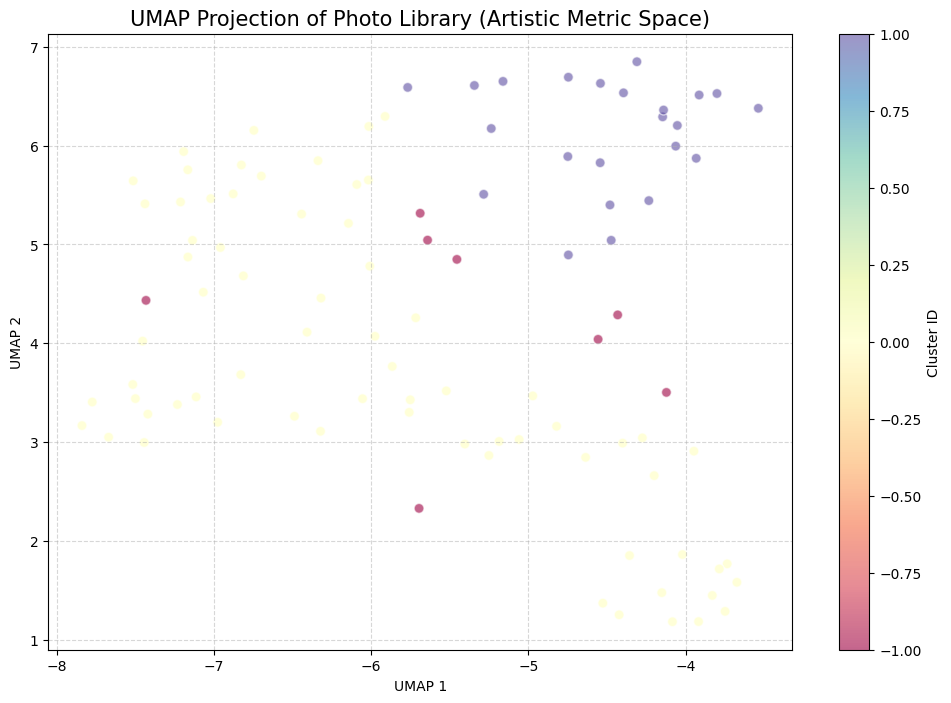


  NOISE (OUTLIERS) | 8 Images


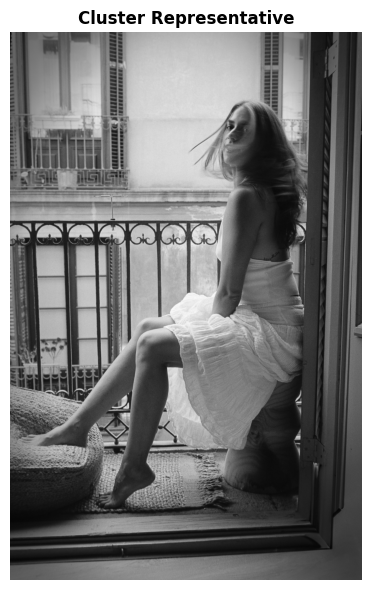

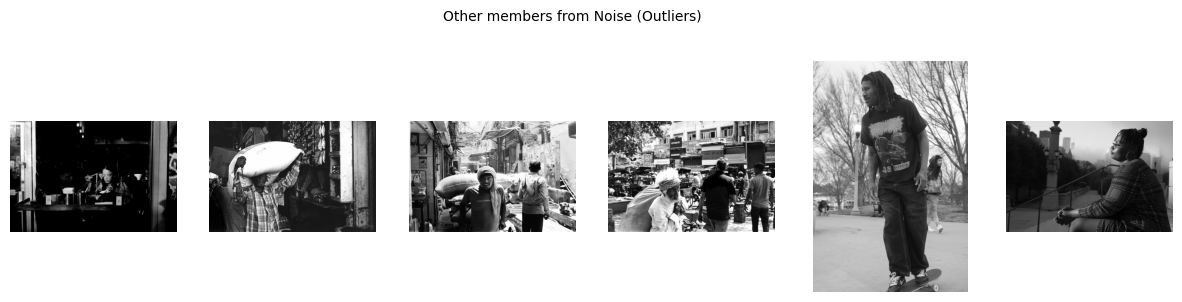


  CLUSTER 0 | 69 Images


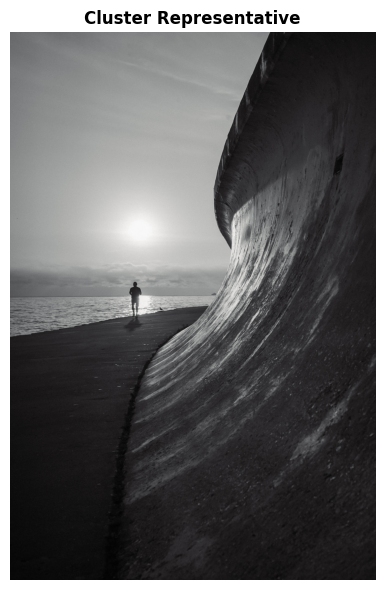

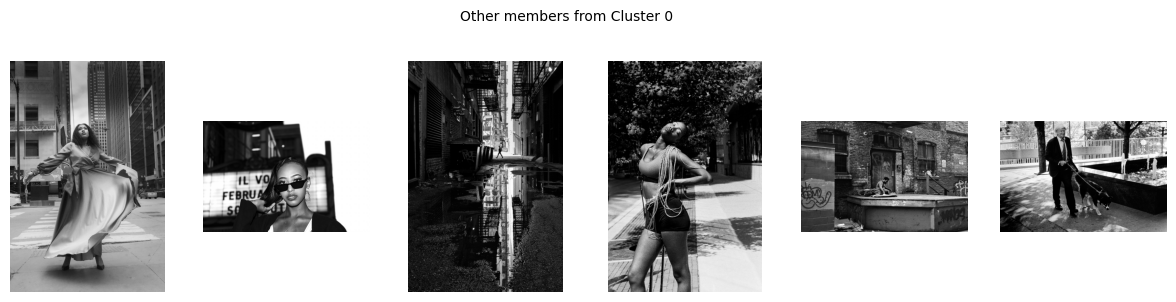


  CLUSTER 1 | 23 Images


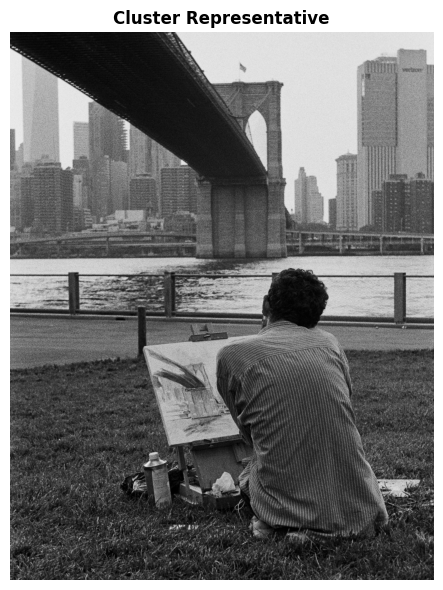

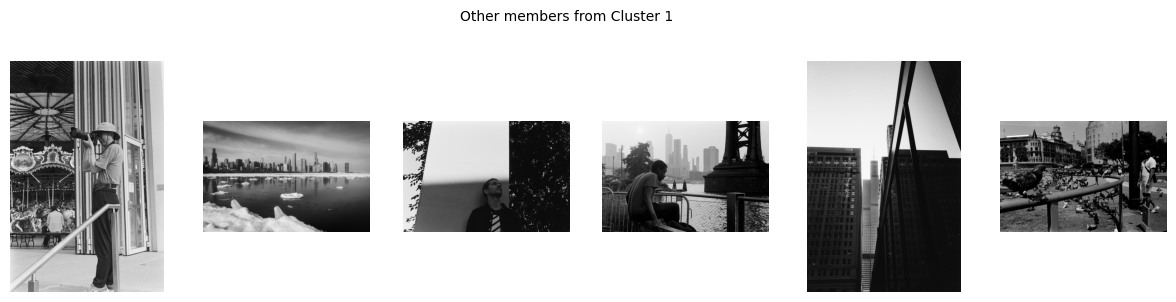

In [12]:
print("[i] Generating Visualizations...")

# --- 1. UMAP Manifold Visualization ---
if 'vis_2d' in locals() and len(vis_2d) > 0:
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(vis_2d[:, 0], vis_2d[:, 1], c=labels, cmap='Spectral', s=50, alpha=0.6, edgecolors='w')
    plt.colorbar(scatter, label='Cluster ID')
    plt.title("UMAP Projection of Photo Library (Artistic Metric Space)", fontsize=15)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# --- 2. Cluster Gallery ---
cluster_results = [
    {
        "cluster_id": cid,
        "representative_path": str(clusters[cid][0]),
        "member_count": len(clusters[cid]),
        "sample_images": [str(p) for p in clusters[cid]],
    }
    for cid in sorted(clusters.keys())
]

for res in cluster_results:
    cluster_id = res["cluster_id"]
    name = "Noise (Outliers)" if cluster_id == -1 else f"Cluster {cluster_id}"
    member_paths = res["sample_images"]

    print(f"\n{'='*80}")
    print(f"  {name.upper()} | {res['member_count']} Images")
    print(f"{'='*80}")

    fig, ax_main = plt.subplots(1, 1, figsize=(6, 6))
    main_img = Image.open(res["representative_path"]).convert("RGB")
    ax_main.imshow(main_img)
    ax_main.set_title("Cluster Representative", fontsize=12, fontweight='bold')
    ax_main.axis("off")
    plt.tight_layout()
    plt.show()

    other_members = [p for p in member_paths if p != res["representative_path"]]
    if other_members:
        samples_to_show = min(6, len(other_members))
        fig, axes = plt.subplots(1, samples_to_show, figsize=(15, 3))
        if samples_to_show == 1: axes = [axes]

        for i in range(samples_to_show):
            s_img = Image.open(other_members[i]).convert("RGB")
            axes[i].imshow(s_img)
            axes[i].axis("off")

        plt.suptitle(f"Other members from {name}", fontsize=10, y=1.05)
        plt.show()

In [13]:
print("[i] Exporting Results...")
with open(RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump(cluster_results, f, indent=2)
print(f"[✓] Results saved to {RESULTS_PATH}")

[i] Exporting Results...
[✓] Results saved to outputs/results_v2.json
